In [3]:
import gspread
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.oauth2.service_account import Credentials

from wordcloud import WordCloud, ImageColorGenerator
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import seaborn as sns

In [4]:
SERVICE_ACCOUNT_FILE = '../../key/Credentials.json'
SCOPES = ['https://www.googleapis.com/auth/spreadsheets',
          'https://www.googleapis.com/auth/drive']

creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
client = gspread.authorize(creds)

sheet = client.open('AI Summary Tagging').worksheet("AI Summary")
data = sheet.get_all_values()

df = pd.DataFrame(data[2:], columns=data[1])
df.to_csv('../../raw_data/ai_summary.csv', index=False)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14352 entries, 0 to 14351
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   No                           14352 non-null  object
 1   Tanggal Pengerjaan           14352 non-null  object
 2   Checker                      14352 non-null  object
 3   ASI/AFI                      14352 non-null  object
 4   Nama Agent                   14352 non-null  object
 5   ID Ticket                    14352 non-null  object
 6   Summary Avail                14352 non-null  object
 7   Case Status                  14352 non-null  object
 8   Waktu Chat                   14352 non-null  object
 9   Sentimen Pengguna            14352 non-null  object
 10  Revisi Sentimen              14352 non-null  object
 11  Masalah Pelanggan            14352 non-null  object
 12  Solusi                       14352 non-null  object
 13  Perselisihan                 14

In [6]:
df_clean = (
    df.copy()
    .drop(columns=['No'])
    .rename(columns=lambda x: x.strip().lower())
    .rename(columns=lambda x: x.replace(' ', '_'))
    .apply(lambda x: x.str.strip().str.lower() if x.dtype == 'object' else x)
)

df_clean = df_clean[df_clean['revisi_sentimen'] == 'negatif']
df_clean

,tanggal_pengerjaan,checker,asi/afi,nama_agent,id_ticket,summary_avail,case_status,waktu_chat,sentimen_pengguna,revisi_sentimen,masalah_pelanggan,solusi,perselisihan,apakah_sudah_terselesaikan?,hasil_summary,alasan_tidak_suka,原因,nama_sampling
297,07/22/2025,azer,afi,silvia puspitasari,20324885,,,2025-07-12 07:20:54,netral,negatif,benar,benar,benar,benar,bad,sentimen pengguna seharusnya 'negatif' dikaren...,用户情绪应该是“消极的”，因为客户抱怨他们已经付费，但应用程序却没有改变。,
436,07/23/2025,neneng,afi,dwi jalu febriyadi,20366091,,,2025-07-15 00:00:39,netral,negatif,salah,benar,benar,benar,bad,"sentimen pengguna seharusnya ""negatif"" karena ...",用户情绪应为“消极”，因为用户抱怨支付问题，而用户投诉应该是抱怨而不是询问。,
449,07/23/2025,neneng,afi,elfina rahmawati,20268626,,,2025-07-08 18:51:16,netral,negatif,salah,benar,benar,benar,bad,"sentimen pengguna seharusnya ""negatif"" karena ...",用户情绪应为“消极”，因为用户抱怨应用程序上的名称无法更改。,
469,07/23/2025,azer,asi,rizaldi ardin wicaksono,20163878,,,2025-07-05 15:43:22,positif,negatif,salah,benar,benar,benar,bad,seharusnya sentimen pengguna negatif dikarenak...,用户情绪应该是消极的，因为用户抱怨某些内容没有被处理。,
472,07/23/2025,azer,asi,rizaldi ardin wicaksono,20205315,,,2025-07-06 16:14:25,netral,negatif,benar,benar,benar,benar,bad,sentimen pengguna seharusnya negatif dikarenak...,用户情绪应该是消极的，因为用户抱怨他们无法进行分期付款交易。,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14321,03/13/2026,reza,asi,qorina lois fadilla,23206700,,chat category,2026-03-13 08:06:20,netral,negatif,salah,benar,,,bad,seharusnya sentimen negatif karena pengguna ad...,,
14325,03/13/2026,neneng,asi,diaz sigit widyasmoro,23187395,,close,2026-03-10 05:35:49,netral,negatif,benar,benar,,,bad,negatif terkendala pengembalian dana,,
14338,03/13/2026,neneng,asi,diaz sigit widyasmoro,23029062,,chat category,2026-02-13 17:36:57,netral,negatif,benar,benar,,,bad,negatif karena kendala transaksi,,
14342,03/13/2026,neneng,asi,diaz sigit widyasmoro,23029317,,chat category,2026-02-13 18:23:57,netral,negatif,benar,benar,,,bad,negatif karena kendala produk tidak sesuai,,


In [7]:
word_string = ' '.join(df_clean['alasan_tidak_suka'].str.lower())
word_string

'sentimen pengguna seharusnya \'negatif\' dikarenakan cust mengeluhkan sudah bayar tapi di aplikasinya tidak berubah sentimen pengguna seharusnya "negatif" karena  user komplain terkait pembayaran dan komplain pengguna seharusnya seharusnya komplain bukan bertanya sentimen pengguna seharusnya "negatif" karena  user komplain terkait nama yang tidak berubah pada aplikasi seharusnya sentimen pengguna negatif dikarenakan user mengeluhkan ada yg belum di proses sentimen pengguna seharusnya negatif dikarenakan user mengeluh tidak bisa transakdi cicilan sentimen pengguna seharusnya negatif dikarenakan use mengelih pembayaran tagihan pinjaman belum masuk (over estimasi) sentimen pada kesimpulan obrolan kula ini seharusnya negatif, karena pada percakapan user mengucapkan keluhannya terkait sudah bayar tagihan pinjaman, tetapi masih muncul. sentimen pada kesimpulan obrolan kula ini seharusnya negatif, karena user mengeluhkan  pembayaran paylater via ovo di hari kamis pukul 21:45 tapi pembayaran 

(np.float64(-0.5), np.float64(899.5), np.float64(899.5), np.float64(-0.5))

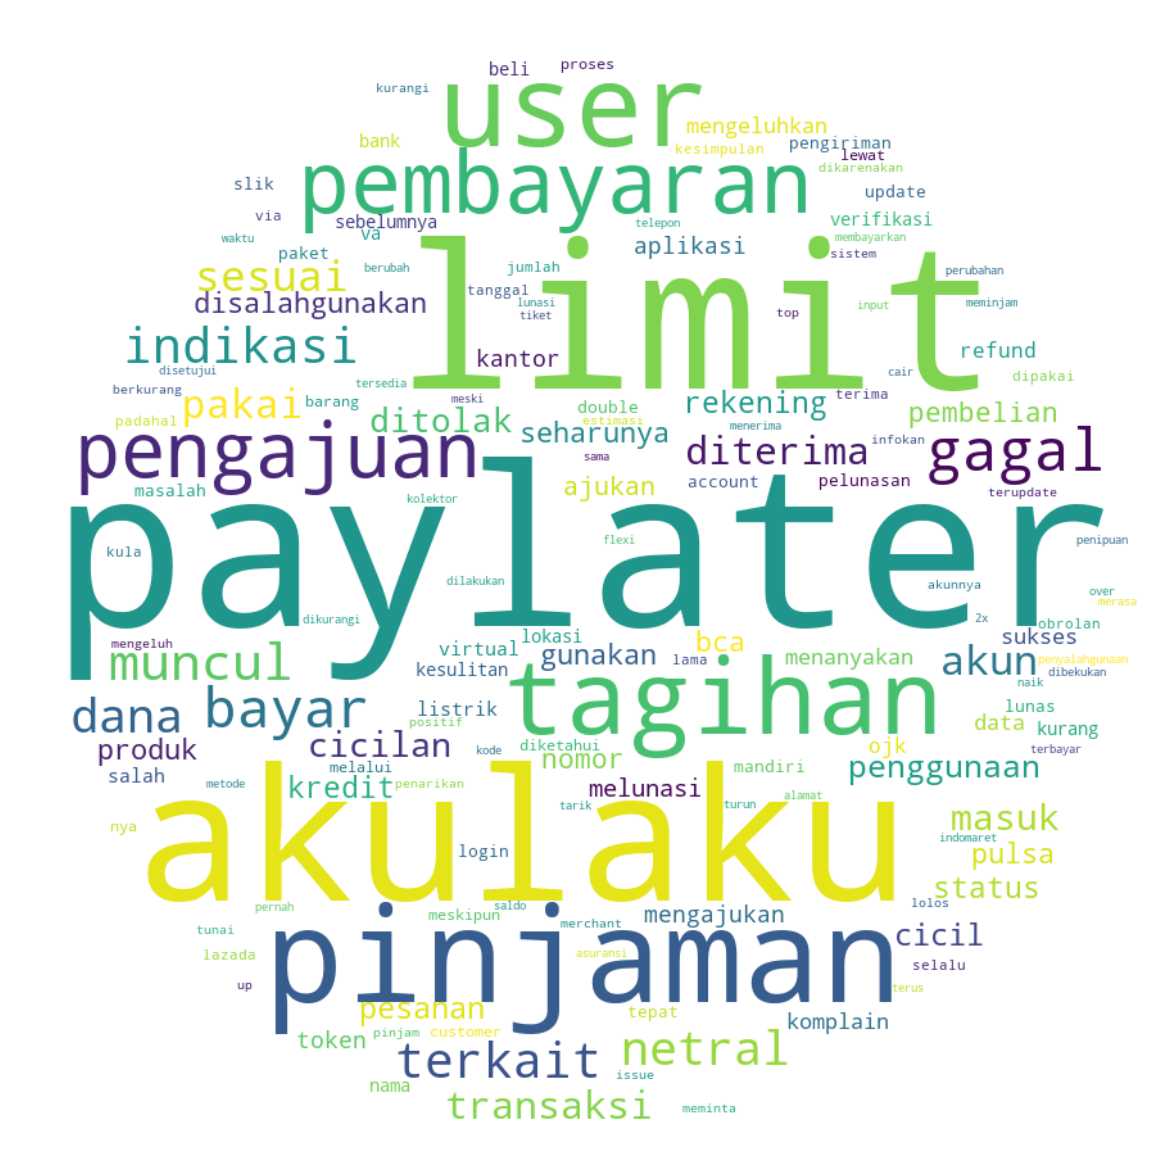

In [10]:
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

custom_stopwords = {
    'pengguna', 'mengalami', 'pengguna mengalami', 'sentimen', 'sentimen negatif', 'negatif', 'terdapat kendala', 'terdapat', 'kendala', 'menggunakan', 'melakukan', 'terkendala', 'keluhan', 'digunakan', 'seharusnya', 'seharunsya'
}

stopwords = stopwords.union(custom_stopwords)

# mask
size = 900
x, y = np.ogrid[:size, :size]
center = size // 2
radius = size // 2 - 20

mask = ((x - center) ** 2 + (y - center) ** 2 > radius ** 2).astype(np.uint8) * 255

plt.figure(figsize=(15,15))

# wordcloud
wc = WordCloud(
    background_color='white',
    stopwords=stopwords,
    mask=mask,
    max_words=500,
    max_font_size=220,
    min_font_size=8,
    width=size,
    height=size,
    prefer_horizontal=1.0,
    collocations=False,
    colormap='Set1',   # bisa ganti: tab10, Set1, Dark2, turbo
    random_state=42
).generate(word_string)

plt.imshow(wc.recolor(colormap='viridis', random_state=17), interpolation='bilinear')
plt.axis('off')

In [ ]:
df_clean['alasan_tidak_suka'] = df_clean['alasan_tidak_suka'].apply(lambda x: remove by (stopwords))

AttributeError: 'ia' is not a valid function for 'Series' object